# Customer Segmentation Analysis

**Internship:** Oasis Infobyte (OIBSIP)

**Track:** Data Analytics

**Task:** Task 2 – Customer Segmentation Analysis

**Tools Used:**

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn
- Google Colab

**Dataset:** Online Retail Dataset

## Objective

The objective of this project is to segment an e-commerce company's customer base into distinct groups based on purchasing behaviour.

RFM (Recency, Frequency, Monetary) analysis is used to identify key customer behaviour features, followed by K-Means clustering to create meaningful customer segments.

The analysis aims to understand different customer types and provide actionable marketing strategies for each segment.

# Import Libraries & Load Dataset

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

plt.style.use("ggplot")
%matplotlib inline

## Load Dataset

In [11]:
from google.colab import files

uploaded = files.upload()
import pandas as pd

df = pd.read_csv("/content/online_retail.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

display(df.head())

Saving online_retail.csv to online_retail.csv
Dataset loaded successfully!
Shape: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


## Initial Data Inspection

The dataset structure, data types, missing values, and duplicate records are examined before performing customer segmentation.

In [12]:
print("Column Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Column Names:
['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']

Data Types:
InvoiceNo       object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
UnitPrice      float64
CustomerID     float64
Country         object
dtype: object

Missing Values:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

Duplicate Rows:
5268


### Observation

- The dataset contains transaction-level information including invoice number, product details, quantity, price, customer ID, and country.
- CustomerID contains missing values, which must be handled because customer-level segmentation requires customer identification.
- Description contains some missing values.
- Duplicate transaction records are present and will be removed during data cleaning.
- InvoiceDate is stored as an object and will be converted to datetime format.

## Data Cleaning

The dataset is cleaned by removing duplicate transactions, handling missing customer IDs, removing missing product descriptions, and excluding invalid transactions with non-positive quantities or prices.

In [13]:
# Convert InvoiceDate to datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Check initial shape
print("Initial Shape:", df.shape)

# Remove duplicate records
df = df.drop_duplicates()

# Remove rows with missing CustomerID
df = df.dropna(subset=['CustomerID'])

# Remove rows with missing Description
df = df.dropna(subset=['Description'])

# Remove invalid quantities and prices
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]

print("Shape after cleaning:", df.shape)

print("\nMissing Values After Cleaning:")
print(df.isnull().sum())

print("\nDuplicate Rows After Cleaning:", df.duplicated().sum())

Initial Shape: (541909, 8)
Shape after cleaning: (392692, 8)

Missing Values After Cleaning:
InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

Duplicate Rows After Cleaning: 0


### Observation

- Duplicate transaction records were removed.
- Transactions without a CustomerID were excluded because they cannot be assigned to a customer segment.
- Records with missing product descriptions were removed.
- Transactions with zero or negative quantities and prices were excluded as invalid purchase records.
- The resulting dataset is suitable for customer-level behavioural analysis.

## Calculate Purchase Value

A new TotalAmount feature is created by multiplying Quantity by UnitPrice. This represents the monetary value of each transaction.

In [30]:
df['TotalAmount'] = df['Quantity'] * df['UnitPrice']

print("TotalAmount column created successfully!")

df[['Quantity', 'UnitPrice', 'TotalAmount']].head()

TotalAmount column created successfully!


,Quantity,UnitPrice,TotalAmount
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


### Observation

The TotalAmount variable represents the revenue generated by each transaction and will be used to calculate the Monetary component of RFM analysis.

## Customer-Level Descriptive Statistics

Customer-level purchasing behaviour is analysed using average purchase value, purchase frequency, and customer lifetime value.

In [31]:
customer_stats = df.groupby('CustomerID').agg(
    Average_Purchase_Value=('TotalAmount', 'mean'),
    Purchase_Frequency=('InvoiceNo', 'nunique'),
    Customer_Lifetime_Value=('TotalAmount', 'sum')
)

print("Customer-level descriptive statistics:")

customer_stats.describe()

Customer-level descriptive statistics:


,Average_Purchase_Value,Purchase_Frequency,Customer_Lifetime_Value
count,4338.000000,4338.000000,4338.000000
mean,68.381590,4.272015,2048.688081
std,1467.918294,7.697998,8985.230220
min,2.136970,1.000000,3.750000
25%,12.393196,1.000000,306.482500
50%,17.755000,2.000000,668.570000
75%,24.878950,5.000000,1660.597500
max,77183.600000,209.000000,280206.020000


In [16]:
print("Average Purchase Value:")
print(customer_stats['Average_Purchase_Value'].mean())

print("\nAverage Purchase Frequency:")
print(customer_stats['Purchase_Frequency'].mean())

print("\nAverage Customer Lifetime Value:")
print(customer_stats['Customer_Lifetime_Value'].mean())

Average Purchase Value:
68.38158951287828

Average Purchase Frequency:
4.272014753342554

Average Customer Lifetime Value:
2048.688080682342


### Observation

- Average Purchase Value represents the typical amount spent per transaction.
- Purchase Frequency represents the number of distinct invoices associated with a customer.
- Customer Lifetime Value is represented by the total amount spent by each customer in the available dataset.
- These measures provide an initial understanding of customer purchasing behaviour before clustering.

## RFM Analysis

RFM analysis is used to identify key behavioural characteristics of customers.

- **Recency:** Number of days since the customer's most recent purchase.
- **Frequency:** Number of unique invoices generated by the customer.
- **Monetary:** Total amount spent by the customer.

In [32]:
# Analysis date
analysis_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

# Create RFM table
rfm = df.groupby('CustomerID').agg(
    Recency=('InvoiceDate',
             lambda x: (analysis_date - x.max()).days),

    Frequency=('InvoiceNo', 'nunique'),

    Monetary=('TotalAmount', 'sum')
)

print("RFM Analysis completed successfully!")

rfm.head()
rfm.describe()

RFM Analysis completed successfully!


,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2048.688081
std,100.014169,7.697998,8985.230220
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,306.482500
50%,51.000000,2.000000,668.570000
75%,142.000000,5.000000,1660.597500
max,374.000000,209.000000,280206.020000


### Observation

- Recency measures how recently each customer made a purchase.
- Frequency measures how frequently customers made purchases.
- Monetary value measures the total amount spent by each customer.
- These three behavioural features will be used as inputs for customer segmentation.

## Data Standardisation

RFM features have different scales and ranges. StandardScaler is used to standardise the variables before applying K-Means clustering so that each feature contributes appropriately to the clustering process.

In [33]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm[['Recency', 'Frequency', 'Monetary']])

rfm_scaled = pd.DataFrame(
    rfm_scaled,
    columns=['Recency', 'Frequency', 'Monetary'],
    index=rfm.index
)
print("RFM data standardized successfully!")
rfm_scaled.head()

RFM data standardized successfully!


,Recency,Frequency,Monetary
CustomerID,,,
12346.0,2.334574,-0.425097,8.363010
12347.0,-0.905340,0.354417,0.251699
12348.0,-0.175360,-0.035340,-0.027988
12349.0,-0.735345,-0.425097,-0.032406
12350.0,2.174578,-0.425097,-0.190812


## Determining Optimal Number of Clusters – Elbow Method

The Elbow Method is used to identify a suitable number of customer segments. The within-cluster sum of squares (inertia) is calculated for different values of K.

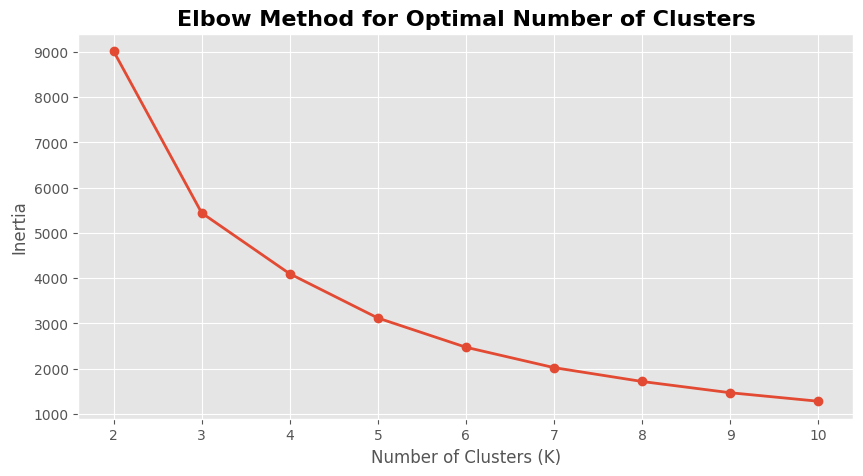

In [34]:
from sklearn.cluster import KMeans
inertia = []

K_range = range(2, 11)

for k in K_range:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(rfm_scaled)

    inertia.append(kmeans.inertia_)


plt.figure(figsize=(10,5))

plt.plot(
    K_range,
    inertia,
    marker='o',
    linewidth=2
)

plt.title(
    "Elbow Method for Optimal Number of Clusters",
    fontsize=16,
    fontweight='bold'
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")

plt.xticks(K_range)

plt.grid(True)

plt.show()

## K-Means Clustering

Based on the Elbow Method, 4 clusters are selected as the optimal number of customer segments.

K-Means clustering is then applied to the standardised RFM features to group customers with similar purchasing behaviour.

In [35]:
# Apply K-Means with 4 clusters
# Final K-Means model with K = 4

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

print("K-Means clustering completed successfully!")

print("\nNumber of customers in each cluster:")

print(
    rfm['Cluster']
    .value_counts()
    .sort_index()
)

K-Means clustering completed successfully!

Number of customers in each cluster:
Cluster
0    3054
1    1067
2      13
3     204
Name: count, dtype: int64


## Clusters profile

The number of customers assigned to each cluster is calculated to understand the size of each customer segment.

Number of Customers in Each Cluster:
Cluster
0    3054
1    1067
2      13
3     204
Name: count, dtype: int64


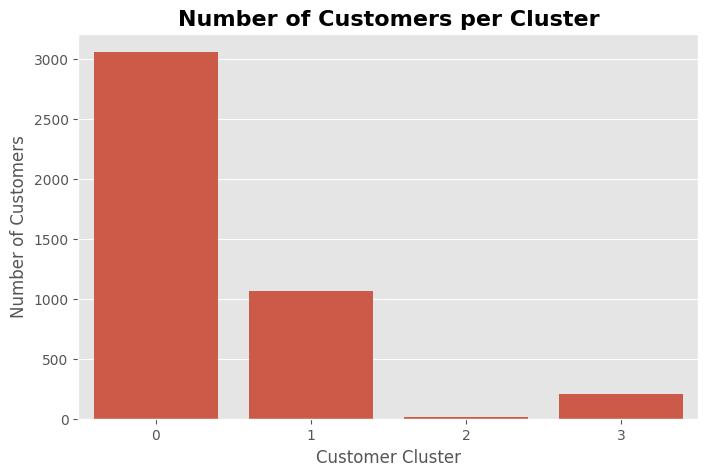

In [21]:
cluster_counts = rfm['Cluster'].value_counts().sort_index()

print("Number of Customers in Each Cluster:")
print(cluster_counts)
plt.figure(figsize=(8,5))

sns.barplot(
    x=cluster_counts.index,
    y=cluster_counts.values
)

plt.title("Number of Customers per Cluster", fontsize=16, fontweight='bold')
plt.xlabel("Customer Cluster")
plt.ylabel("Number of Customers")

plt.show()

### Observation

- The customer base is divided into four distinct clusters based on Recency, Frequency, and Monetary behaviour.
- The number of customers varies across the clusters, indicating that some customer groups are more common than others.
- The cluster sizes provide an initial understanding of the distribution of different customer behaviours.

## Cluster Profiling

The average Recency, Frequency, and Monetary values of each cluster are calculated to understand the purchasing behaviour of each customer segment.

In [36]:
cluster_profile = rfm.groupby(
    'Cluster'
)[['Recency', 'Frequency', 'Monetary']].mean().round(2)

print("Cluster Profile:")

display(cluster_profile)

Cluster Profile:


,Recency,Frequency,Monetary
Cluster,,,
0,43.70,3.68,1353.63
1,248.08,1.55,478.85
2,7.38,82.54,127187.96
3,15.50,22.33,12690.50


# Name the Customer Types

In [37]:
cluster_names = {
    0: "Regular Customers",
    1: "At-Risk / Inactive Customers",
    2: "High-Value Loyal Customers",
    3: "Loyal High-Spending Customers"
}

rfm['Customer Type'] = rfm['Cluster'].map(cluster_names)

print("Customer segments assigned successfully!")

display(
    rfm[['Cluster', 'Customer Type']]
    .head()
)

Customer segments assigned successfully!


,Cluster,Customer Type
CustomerID,,
12346.0,3,Loyal High-Spending Customers
12347.0,0,Regular Customers
12348.0,0,Regular Customers
12349.0,0,Regular Customers
12350.0,1,At-Risk / Inactive Customers


# Bar Chart

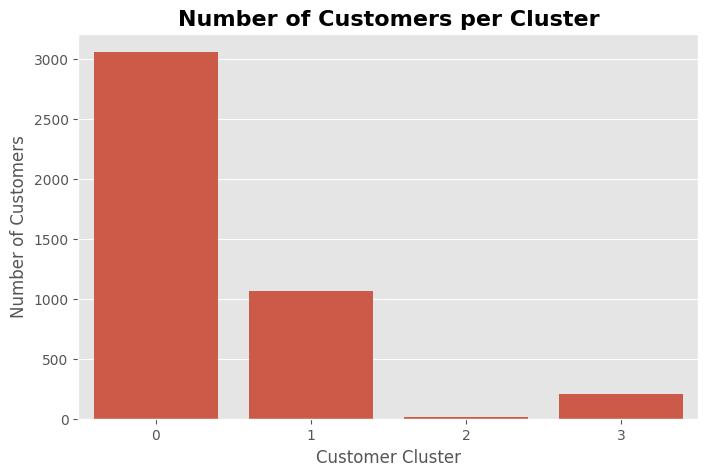

In [39]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=cluster_counts.index,
    y=cluster_counts.values
)

plt.title(
    "Number of Customers per Cluster",
    fontsize=16,
    fontweight='bold'
)

plt.xlabel("Customer Cluster")
plt.ylabel("Number of Customers")

plt.show()

### Observation

- The bar chart shows the distribution of customers across the four customer segments.
- The clusters contain different numbers of customers because purchasing behaviour varies among customers.
- The different segment sizes indicate that customers should be targeted using different marketing strategies.

## Cluster Visualisation - Scatter plots

Customer clusters are visualised using different combinations of RFM features to identify behavioural differences between customer segments.

#Visualisation: Frequency vs Monetary

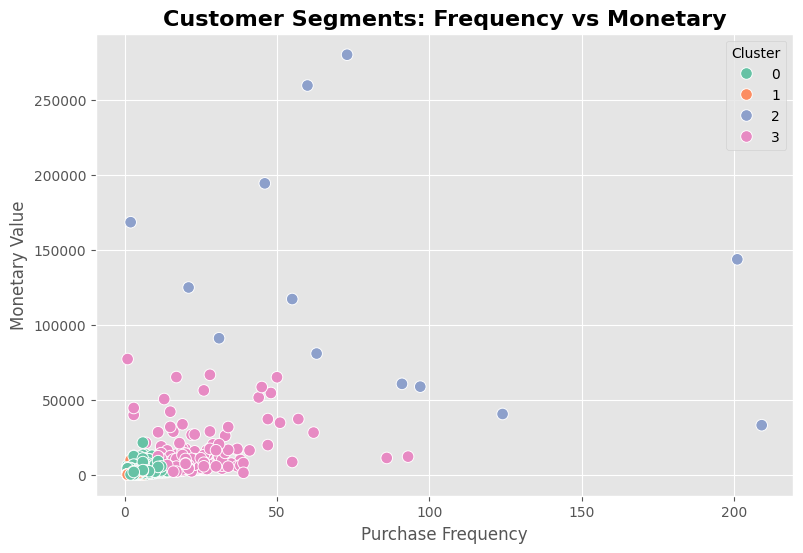

In [40]:
plt.figure(figsize=(9,6))

sns.scatterplot(
    data=rfm,
    x='Frequency',
    y='Monetary',
    hue='Cluster',
    palette='Set2',
    s=70
)

plt.title(
    "Customer Segments: Frequency vs Monetary",
    fontsize=16,
    fontweight='bold'
)

plt.xlabel("Purchase Frequency")
plt.ylabel("Monetary Value")

plt.legend(title="Cluster")

plt.show()

### Observation

- The scatter plot shows the relationship between purchase frequency and monetary value.
- Customers in the high-value clusters show higher purchasing frequency and spending.
- The clusters demonstrate that customer purchasing behaviour differs considerably across the customer base.

#Visualisation: Recency vs Monetary

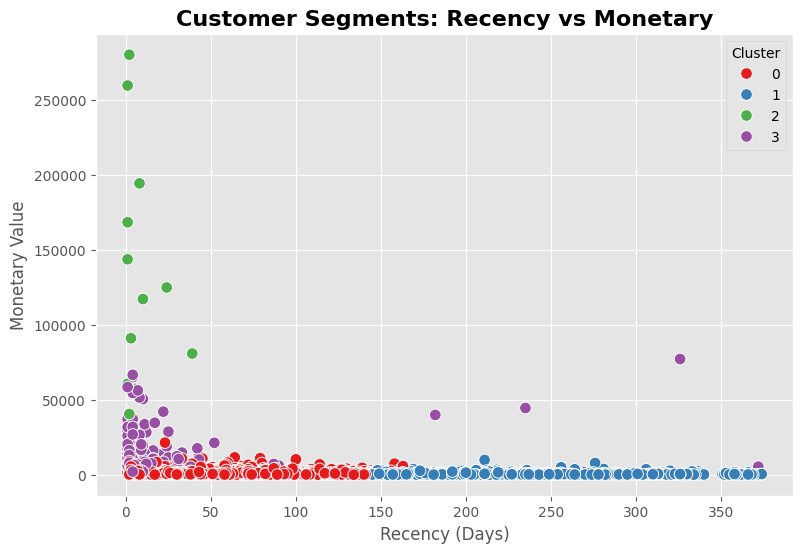

In [41]:
plt.figure(figsize=(9,6))

sns.scatterplot(
    data=rfm,
    x='Recency',
    y='Monetary',
    hue='Cluster',
    palette='Set1',
    s=70
)

plt.title(
    "Customer Segments: Recency vs Monetary",
    fontsize=16,
    fontweight='bold'
)

plt.xlabel("Recency (Days)")
plt.ylabel("Monetary Value")

plt.legend(title="Cluster")

plt.show()

### Observation

- The plot compares customer recency with their monetary contribution.
- Customers with low Recency values have purchased more recently.
- Cluster 2 contains customers with very recent purchases and exceptionally high monetary value.
- Cluster 1 has high Recency and low Monetary values, indicating inactive or at-risk customers.

# Additional Visualization

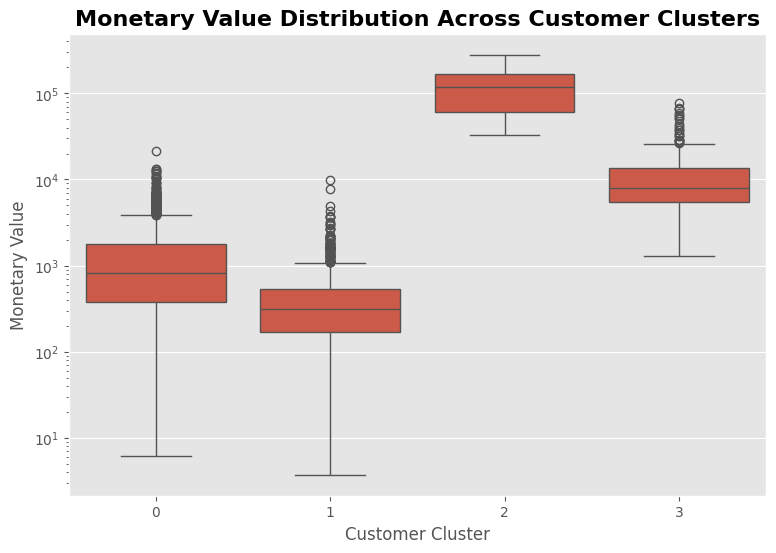

In [42]:
plt.figure(figsize=(9,6))

sns.boxplot(
    data=rfm,
    x='Cluster',
    y='Monetary'
)

plt.title(
    "Monetary Value Distribution Across Customer Clusters",
    fontsize=16,
    fontweight='bold'
)

plt.xlabel("Customer Cluster")
plt.ylabel("Monetary Value")

plt.yscale('log')

plt.show()

### Observation

- The boxplot shows the variation in monetary value within each customer segment.
- The distribution demonstrates that some customers contribute substantially more revenue than others.
- High-value customers therefore require stronger retention strategies because losing a small number of these customers could have a significant impact on revenue.

# Final Cluster Summary

In [44]:
# Final Cluster Summary

final_summary = rfm.groupby(
    ['Cluster', 'Customer Type']
).agg(
    Number_of_Customers=('Recency', 'count'),
    Average_Recency=('Recency', 'mean'),
    Average_Frequency=('Frequency', 'mean'),
    Average_Monetary=('Monetary', 'mean')
).round(2)

display(final_summary)

,,Number_of_Customers,Average_Recency,Average_Frequency,Average_Monetary
Cluster,Customer Type,,,,
0,Regular Customers,3054,43.70,3.68,1353.63
1,At-Risk / Inactive Customers,1067,248.08,1.55,478.85
2,High-Value Loyal Customers,13,7.38,82.54,127187.96
3,Loyal High-Spending Customers,204,15.50,22.33,12690.50


# Insights and Marketing Recommendations

## Cluster 0 – Regular Customers

These customers have moderate recency, purchase frequency, and monetary value.

### Recommended Marketing Actions
- Provide personalized product recommendations.
- Offer loyalty rewards to encourage repeat purchases.
- Use targeted promotions to increase purchase frequency.
- Encourage cross-selling of related products.

---

## Cluster 1 – At-Risk / Inactive Customers

These customers have high recency and comparatively low frequency and monetary value.

### Recommended Marketing Actions
- Launch win-back campaigns.
- Provide personalized reactivation offers.
- Send reminders based on previous purchases.
- Use limited-time promotions to encourage customers to return.

---

## Cluster 2 – High-Value Loyal Customers

These customers have extremely low recency, very high frequency, and the highest monetary value.

### Recommended Marketing Actions
- Create a VIP loyalty program.
- Provide exclusive rewards and early access to products.
- Offer personalized recommendations.
- Focus on retention rather than aggressive discounting.

---

## Cluster 3 – Loyal High-Spending Customers

These customers purchase frequently and recently and contribute substantial revenue.

### Recommended Marketing Actions
- Provide premium loyalty rewards.
- Use personalized offers.
- Encourage repeat purchases.
- Apply cross-selling and upselling strategies.

---

## Overall Marketing Insight

The analysis demonstrates that customers have significantly different purchasing behaviours. Therefore, the business should avoid applying the same marketing strategy to every customer.

Instead, marketing campaigns should be customized according to each customer's RFM-based segment.

# Conclusion

The customer segmentation analysis successfully grouped the e-commerce customer base into four distinct segments using RFM analysis and K-Means clustering.

The analysis identified significant differences in customer recency, purchasing frequency, and monetary contribution.

### Key Business Recommendations

1. **Retain high-value customers:**  
   High-value loyal customers should receive VIP benefits, exclusive rewards, and personalized experiences to strengthen customer retention.

2. **Re-engage inactive customers:**  
   At-risk customers should be targeted with win-back campaigns, personalized offers, and limited-time promotions.

3. **Increase customer purchase frequency:**  
   Regular customers can be encouraged to purchase more frequently through loyalty programs, personalized recommendations, and cross-selling.

4. **Use segment-specific marketing:**  
   Marketing strategies should be customized according to each customer segment instead of using a single strategy for the entire customer base.

Overall, RFM analysis combined with K-Means clustering provides a practical data-driven approach for understanding customer behaviour and developing targeted marketing strategies.